# Проект: Предсказание сердечных приступов

## 🎯 Цель работы
Разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

## 📋 Описание проекта
В этом проекте предполагается работа с датасетом из открытого источника. Необходимо разработать модель машинного обучения, а также подготовить библиотеку и интерфейс к ней для предсказания на тестовой выборке. В начале проекта вам будет доступен обучающий датасет и тестовый датасет, не содержащий правильных ответов. Метрика на тестовом датасете будет измерена в ходе проверки работы.

## 📊 Ожидаемые результаты проекта
- ***Исследование датасета*** (предполагается поиск дополнительной информации для лучшего понимания природы данных)
- ***Предобработка данных***. Будьте внимательны: в данных могут быть бесполезные признаки, сильно скорелированные признаки а также косвенные утечки целевого признака. Некоторые колонки потребуется преобразовать к нужному типу данных.
- ***Обучение модели***
- ***Подготовка предсказания на тестовой выборке**. Файл предсказаний должен быть в csv формате и содержать 2 столбца: “id” и “prediction”. 
- ***Подготовка скриптов и библиотеки для обработки данных и предсказания на тестовой выборке***
- ***Написание инструмента для тестирования***
- ***Оформление документации***

## GitHub:
https://github.com/sandyclawz/hearth_attacks

***Данные пациентов для предсказания риска сердечных приступов***:
- id  - id
- Антропометрические параметры (вес, возраст, рост)
- Привычки (курение, качество сна и т.д)
- Давление
- Наличие хронических заболеваний
- Биохимия крови
- Таргет - высокий или низкий риск поражения сердца

***Стек***:
- Python (ООП)
- Pandas
- numpy
- Scikitlearn
- CatBoost
- FastAPI
- HTML

# Загружаем все модули Python

In [1]:
#Загружаем все модули
#!pip install phik
!pip -q install shap
#!pip install scikit-learn==1.1.3 -q
#!pip install --upgrade jupyterlab_widgets ipywidgets

#загружаем библиотеки
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#import phik

from pathlib import Path
from IPython.display import display, HTML
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
#from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, recall_score, precision_score, precision_recall_curve
from sklearn.metrics import roc_auc_score, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.datasets import fetch_california_housing
#from phik.report import plot_correlation_matrix


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Задаем константы

In [2]:
RANDOM_STATE=42

# Создаём функции/классы

In [3]:
# Загрузка файлов обработки
def load_csv(path: str | Path) -> pd.DataFrame:

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    df = pd.read_csv(path, sep=",")
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")
    return df

# Проверить общую информацию
def data_review(df, name):
    print(f'=== {name} ===')
    display(df.head(5))
    print()
    print(df.info())
    print()
    print('Пропуски:')
    print(df.isna().sum())
    print()
    print('Полные дубликаты:', df.duplicated().sum())
    print('Дубликаты id:', df['id'].duplicated().sum())
    print('-' * 50)

# Приведение название колонок к snake
def clean_column_names(df):
    df = df.copy()
    
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[()]", "", regex=True)
        .str.replace("-", "_", regex=False)
    )
    
    return df

In [4]:
class DataPreprocessor:
    def __init__(self):
        self.target_col = "heart_attack_risk_binary"
        self.id_col = "id"

    def clean_column_names(self, df):
        df = df.copy()
        
        df.columns = (
            df.columns
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", "_", regex=True)
            .str.replace(r"[()]", "", regex=True)
            .str.replace("-", "_", regex=False)
        )
        
        return df

    def clean_gender(self, df):
        df = df.copy()
        
        gender_map = {
            "Male": "male",
            "Female": "female",
            "1.0": "male",
            "0.0": "female",
            1.0: "male",
            0.0: "female",
            1: "male",
            0: "female"
        }
        
        if "gender" in df.columns:
            df["gender"] = df["gender"].replace(gender_map)
        
        return df

    def prepare_features(self, df):
        df = self.clean_column_names(df)
        df = self.clean_gender(df)
        
        ids = df[self.id_col] if self.id_col in df.columns else None
        
        X = df.drop(
            columns=[self.id_col, self.target_col, "unnamed:_0"],
            errors="ignore"
        )
        
        return X, ids

# Загрузка данных

## Загружаем и анализируем данные

In [5]:
DATA_DIR = Path("../data/raw")
train = load_csv(DATA_DIR / "heart_train.csv")
test = load_csv(DATA_DIR / "heart_test.csv")

In [6]:
data_review(train, 'Данные для тренировки')
data_review(test, 'Данные для теста')

=== Данные для тренировки ===


,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8685 non-null   float64
 1   Cholesterol                      8685 non-null   float64
 2   Heart rate                       8685 non-null   float64
 3   Diabetes                         8442 non-null   float64
 4   Family History                   8442 non-null   float64
 5   Smoking                          8442 non-null   float64
 6   Obesity                          8442 non-null   float64
 7   Alcohol Consumption              8442 non-null   float64
 8   Exercise Hours Per Week          8685 non-null   float64
 9   Diet                             8685 non-null   int64  
 10  Previous Heart Problems          8442 non-null   float64
 11  Medication Use                   8442 non-null   float64
 12  Stress Level       

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,...,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,...,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,...,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,...,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,...,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              966 non-null    float64
 1   Cholesterol                      966 non-null    float64
 2   Heart rate                       966 non-null    float64
 3   Diabetes                         935 non-null    float64
 4   Family History                   935 non-null    float64
 5   Smoking                          935 non-null    float64
 6   Obesity                          935 non-null    float64
 7   Alcohol Consumption              935 non-null    float64
 8   Exercise Hours Per Week          966 non-null    float64
 9   Diet                             966 non-null    int64  
 10  Previous Heart Problems          935 non-null    float64
 11  Medication Use                   935 non-null    float64
 12  Stress Level         

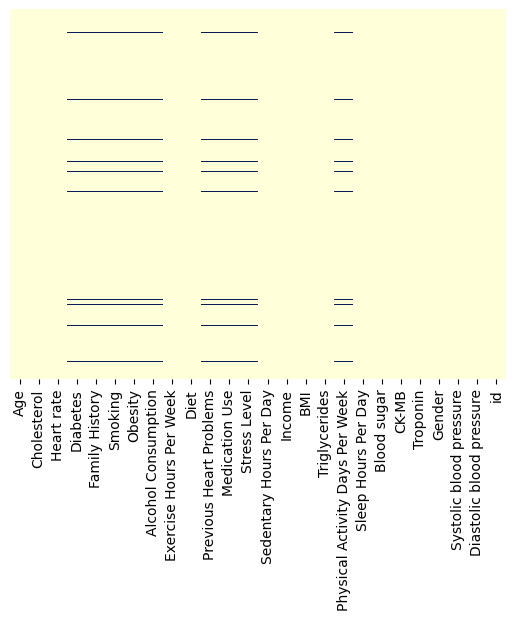

In [7]:
#Визуализация пропусков
sns.heatmap(train.isna(), yticklabels=False, cbar=False, cmap="YlGnBu");
sns.heatmap(test.isna(), yticklabels=False, cbar=False, cmap="YlGnBu");

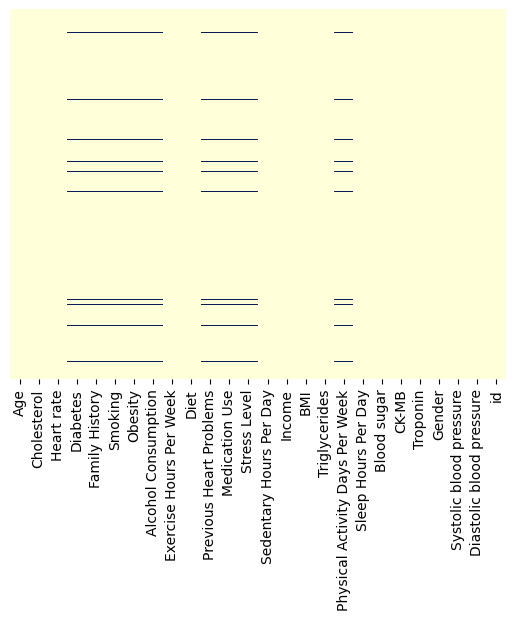

In [8]:
#Визуализация пропусков
sns.heatmap(test.isna(), yticklabels=False, cbar=False, cmap="YlGnBu");

Полных дупликатов нет.

Пропуски в данных оставляем для дальнейшей работы и обработке на стадии паплайна.


## Приводим название колонок и типы данных

In [9]:
train = clean_column_names(train)
test = clean_column_names(test)

TARGET = "heart_attack_risk_binary"
ID_COL = "id"

numeric_cols = [
    "age",
    "cholesterol",
    "heart_rate",
    "exercise_hours_per_week",
    "sedentary_hours_per_day",
    "income",
    "bmi",
    "triglycerides",
    "sleep_hours_per_day",
    "blood_sugar",
    "ck_mb",
    "troponin",
    "systolic_blood_pressure",
    "diastolic_blood_pressure"
]

binary_cols = [
    "diabetes",
    "family_history",
    "smoking",
    "obesity",
    "alcohol_consumption",
    "previous_heart_problems",
    "medication_use"
]

ordinal_cols = [
    "diet",
    "stress_level",
    "physical_activity_days_per_week"
]

categorical_cols = [
    "gender"
]

#Унификация гендера
gender_map = {
    "Male": "male",
    "Female": "female",
    "1.0": "male",
    "0.0": "female",
    1.0: "male",
    0.0: "female",
    1: "male",
    0: "female"
}

for df in [train, test]:
    df["gender"] = df["gender"].replace(gender_map).astype("category")
    df[ID_COL] = df[ID_COL].astype(int)

for col in binary_cols + ordinal_cols + [TARGET]:
    if col in train.columns:
        train[col] = train[col].astype("Int64")

for col in binary_cols + ordinal_cols:
    if col in test.columns:
        test[col] = test[col].astype("Int64")

types_report = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing_share": train.isna().mean().round(4),
    "n_unique": train.nunique()
}).reset_index(drop=True)

display(types_report)

,column,dtype,missing,missing_share,n_unique
0,age,float64,0,0.000,77
1,cholesterol,float64,0,0.000,282
2,heart_rate,float64,0,0.000,87
3,diabetes,Int64,243,0.028,2
4,family_history,Int64,243,0.028,2
5,smoking,Int64,243,0.028,2
6,obesity,Int64,243,0.028,2
7,alcohol_consumption,Int64,243,0.028,2
8,exercise_hours_per_week,float64,0,0.000,7933
9,diet,Int64,0,0.000,4


## 📋 Вывод по пропускам и дубликатам

Полные дубликаты и дубликаты по `id` в обучающей и тестовой выборках отсутствуют. Это говорит о том, что данные не содержат повторяющихся записей пациентов.

Пропуски обнаружены в одинаковом наборе признаков в train и test: `Diabetes`, `Family History`, `Smoking`, `Obesity`, `Alcohol Consumption`, `Previous Heart Problems`, `Medication Use`, `Stress Level`, `Physical Activity Days Per Week`. В обучающей выборке в каждой из этих колонок пропущено по 243 значения, в тестовой — по 31 значению.

Доля пропусков невелика: около 2.8% в train и около 3.2% в test. Удалять строки с пропусками нецелесообразно, так как это приведёт к потере данных и не решит проблему для тестовой выборки. Пропуски будут обработаны на этапе предобработки: для бинарных и дискретных признаков целесообразно использовать заполнение наиболее частым значением или отдельную категорию/индикатор пропуска.

Целевой признак `Heart Attack Risk (Binary)` пропусков не содержит.